# Script to interact with CFR Insights API web site and plot KPIs

In [1]:
%matplotlib widget
import json
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
retry_strategy = Retry(
    total=10,
    backoff_factor=1
)
adapter = HTTPAdapter(max_retries=retry_strategy)

# Generate CFR insights for DOC (agency_id=45) for different dates - this step will take a few minutes to complete

In [3]:
AGENCY_ID = 45

In [4]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    dates = ["2025-06-03", "2024-06-03", "2023-06-03", "2022-06-03", "2021-06-03", "2020-06-03"]
    for date in dates:
        json_data = json.dumps({"agency_id": f"{AGENCY_ID}", "date": date})
        response = session.post("http://127.0.0.1:8000/insights", data=json_data)
        print(response.status_code, response.text)

201 null

201 null

201 null

201 null

201 null

201 null



# Get the generated insights for DOC

In [5]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    response = session.get(f"http://127.0.0.1:8000/insights/agency/{AGENCY_ID}")
    data = response.json()

# Each Reference id represents one unique CFR reference for an agency; group insights by reference id. 

In [6]:
insights_by_reference_id = dict()
for insight in data:
    if insight["cfr_reference_id"] not in insights_by_reference_id:
        insights_by_reference_id[insight["cfr_reference_id"]] = list()
    insights_by_reference_id[insight["cfr_reference_id"]].append(insight)

# Plot how "Word Count" and "Restrictive Terms Count" have changed over time for each CFR reference in DOC
# Increasing "Word Count" and increasing "Restrictive Terms Count" could indicate more and stricter regulations over time

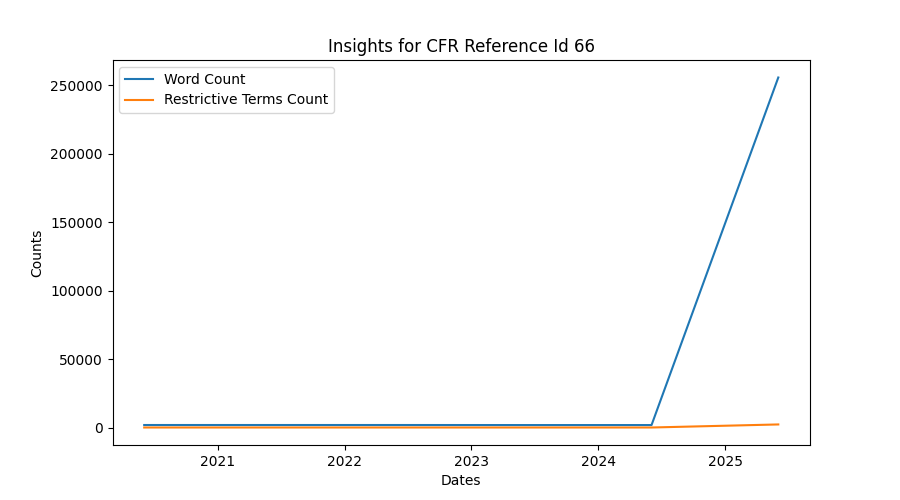

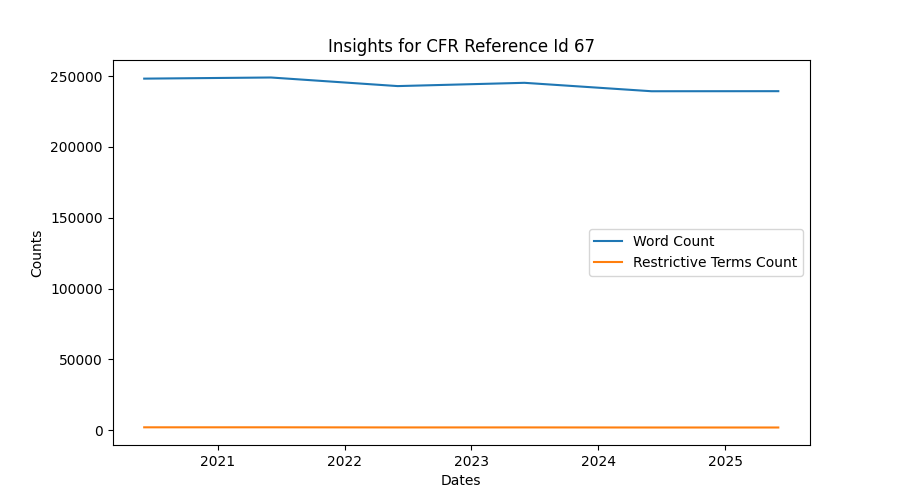

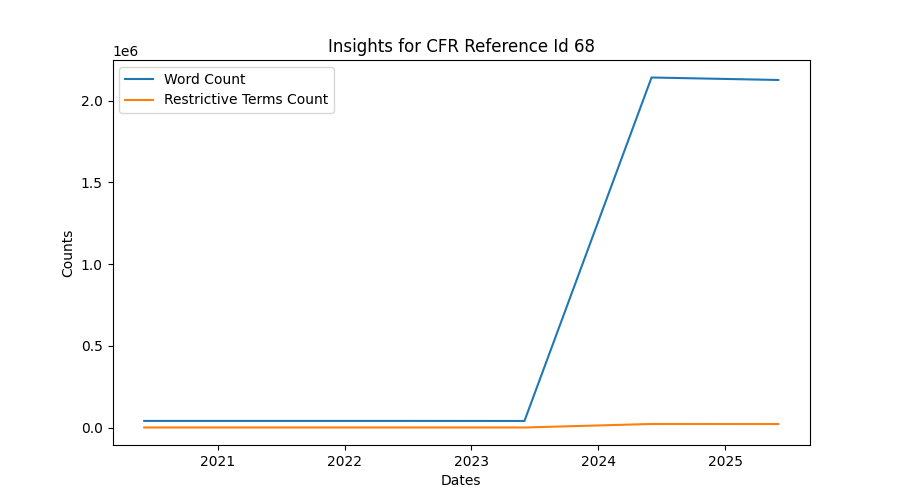

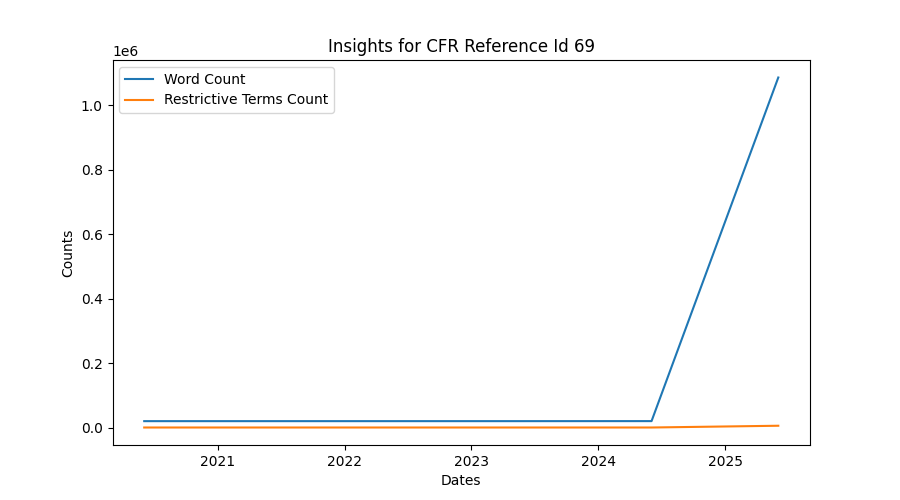

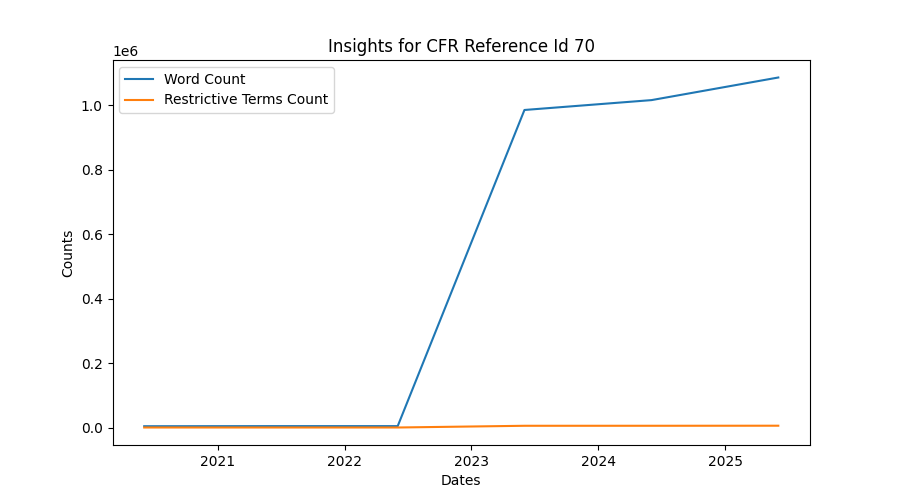

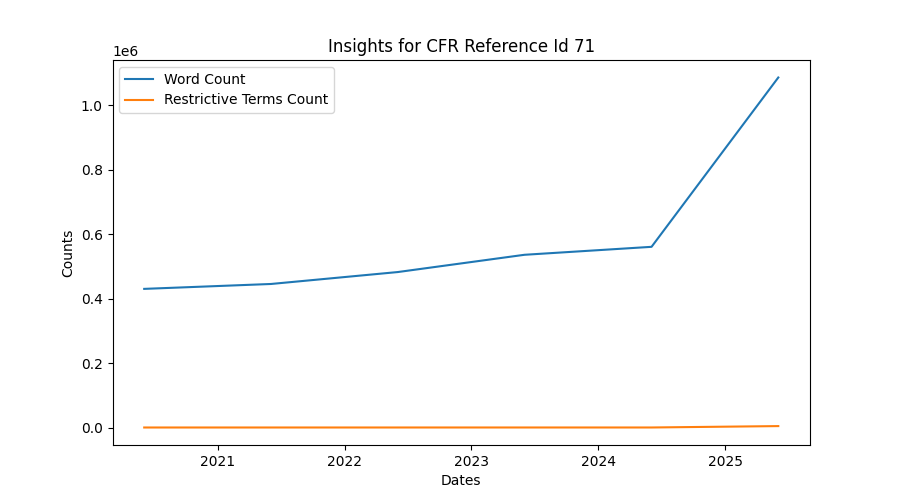

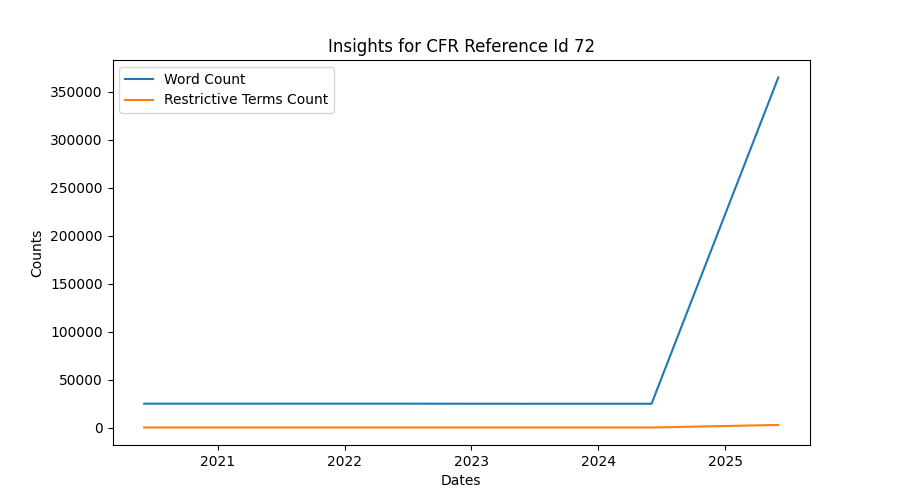

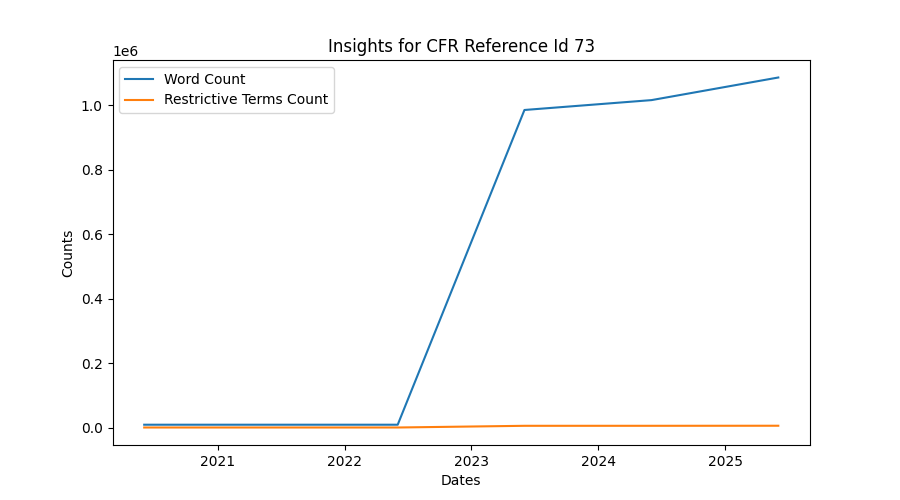

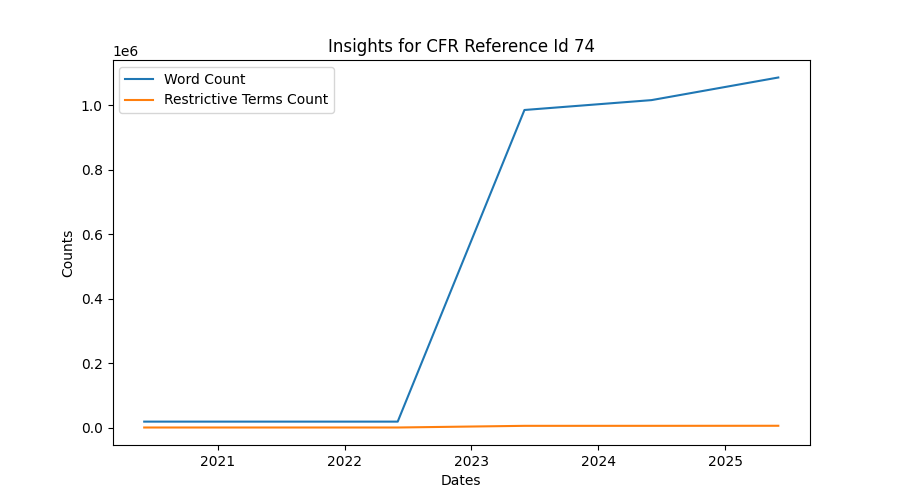

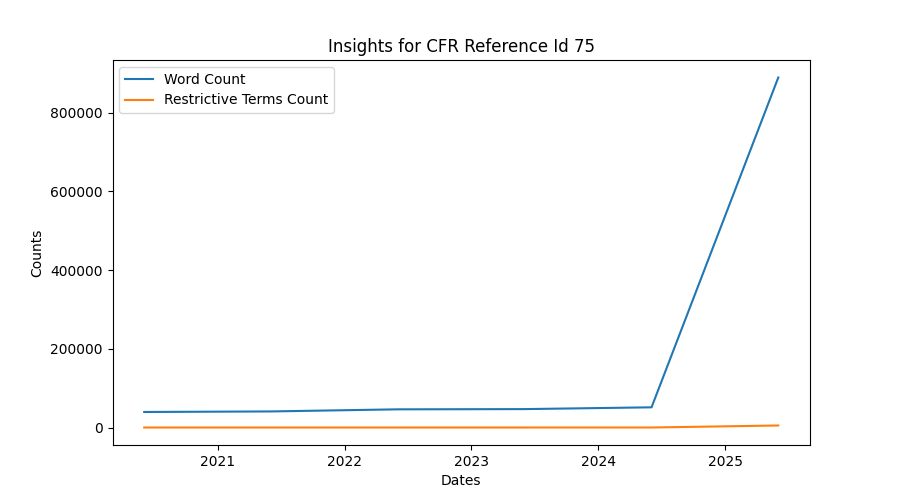

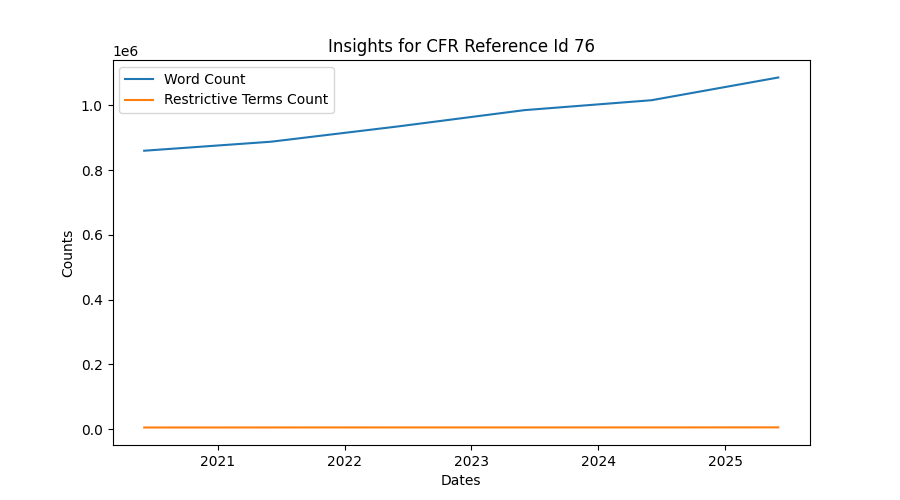

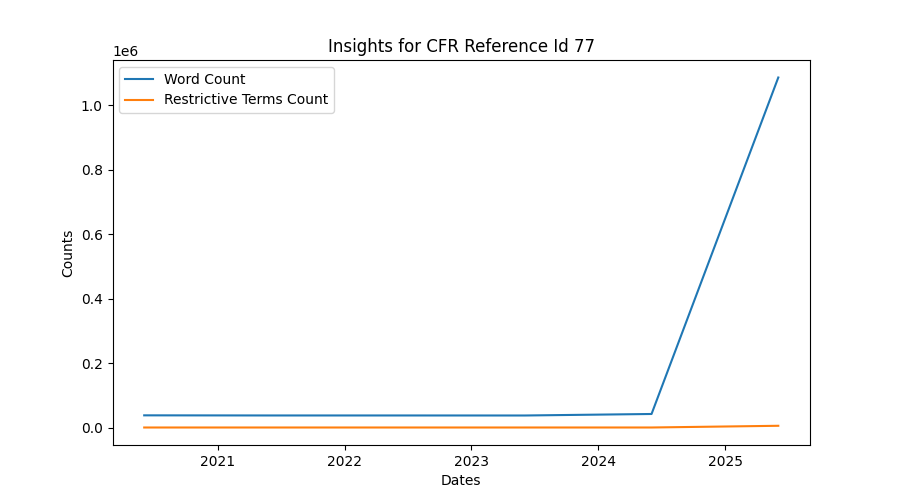

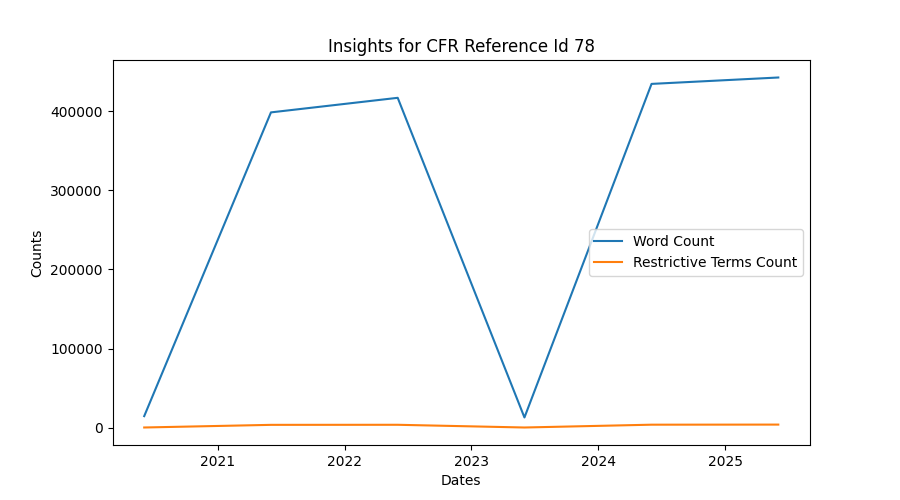

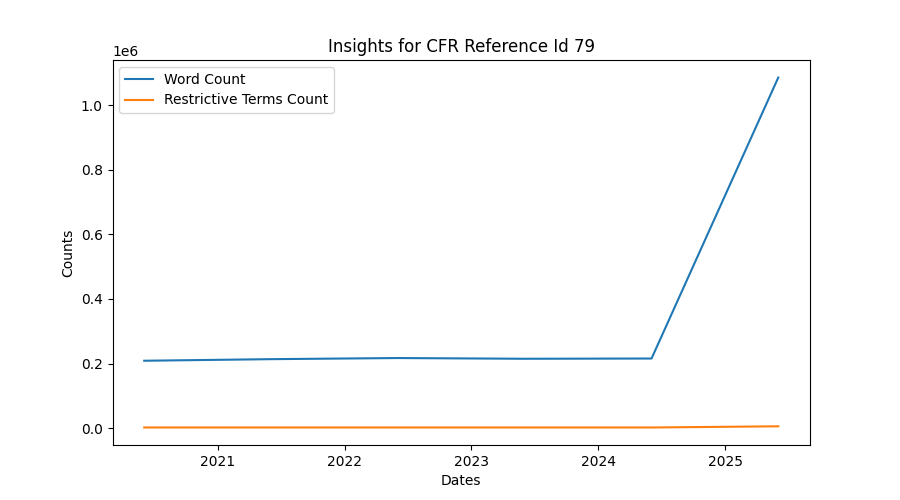

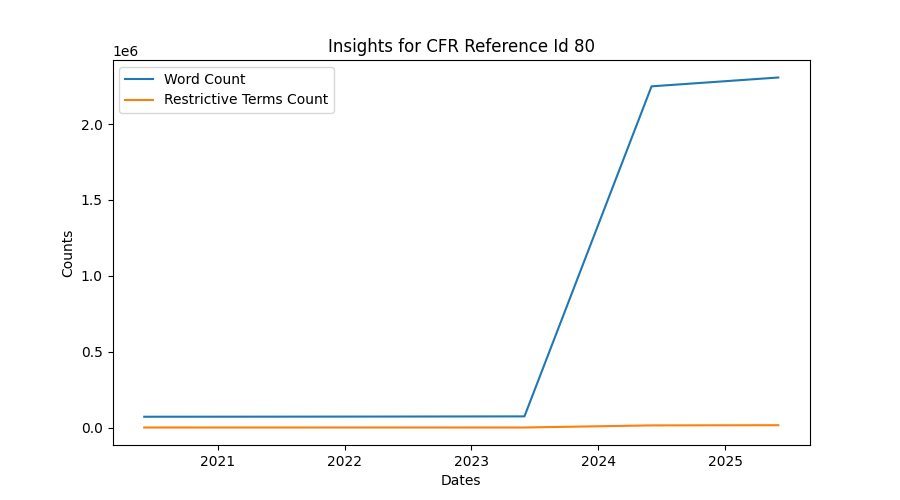

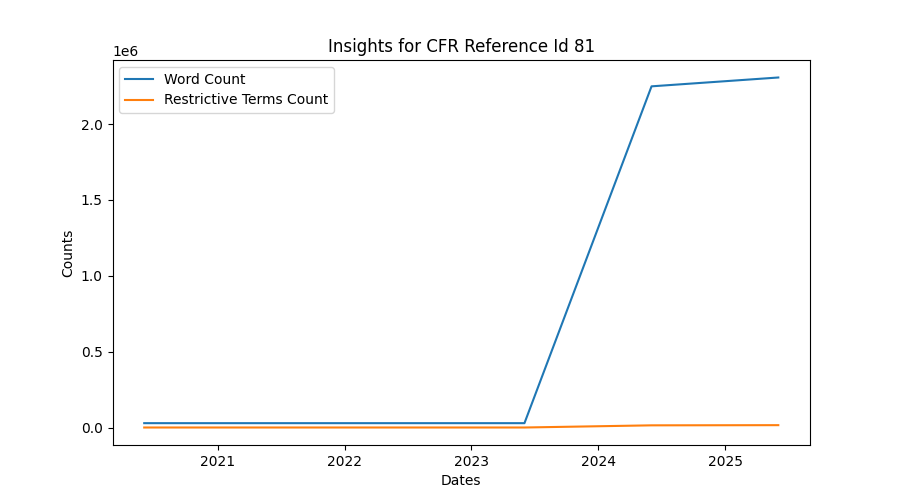

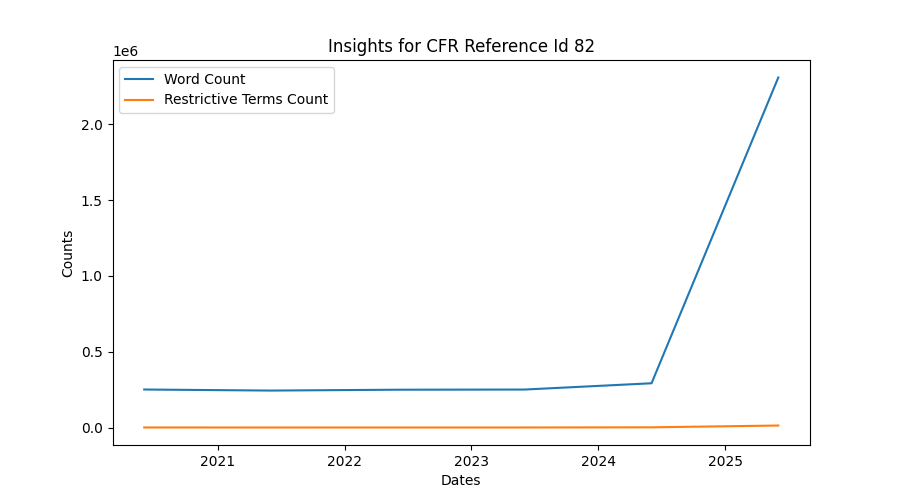

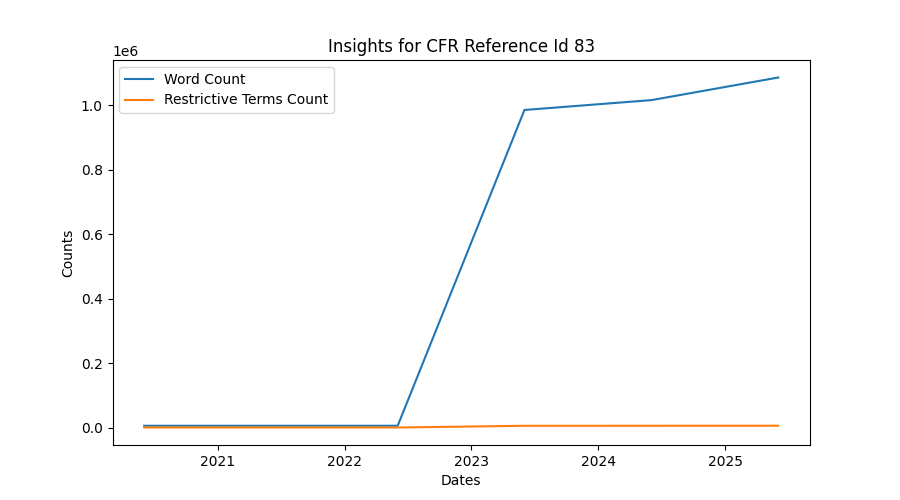

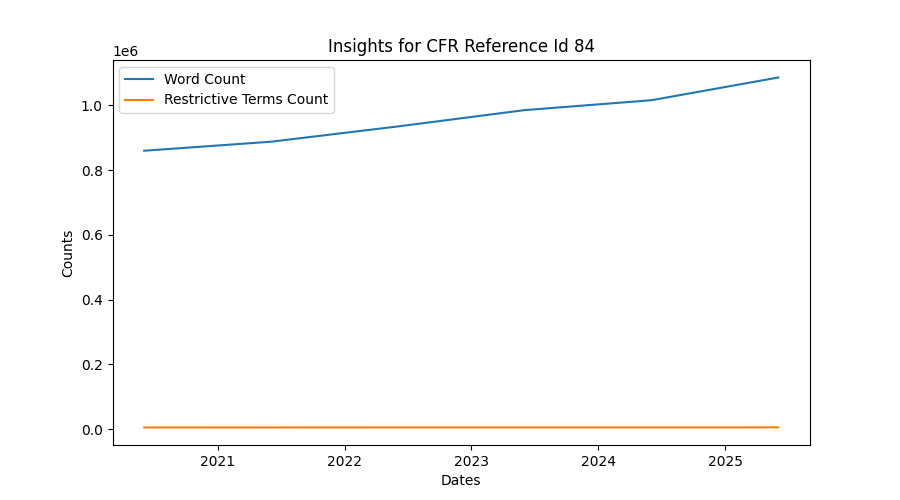

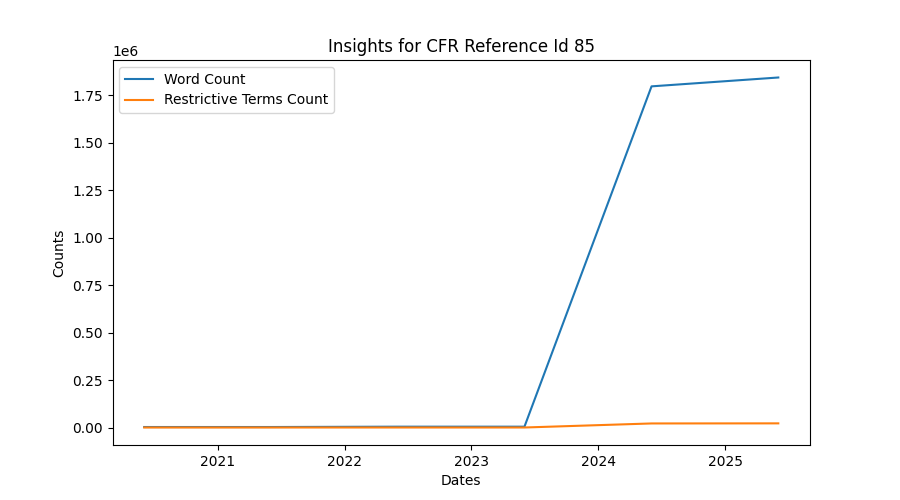

/var/folders/b6/mty8z4pn21vcb02l2tmrc22m0000gn/T/ipykernel_5731/3752845909.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(9, 5))


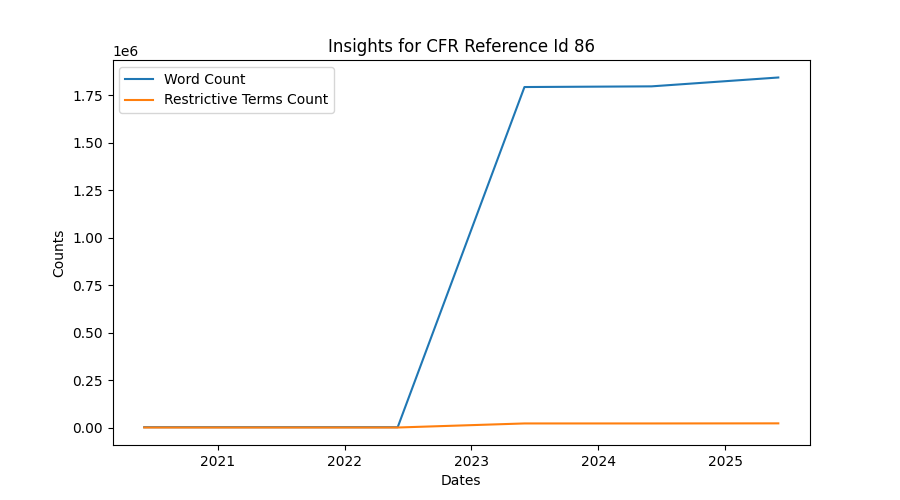

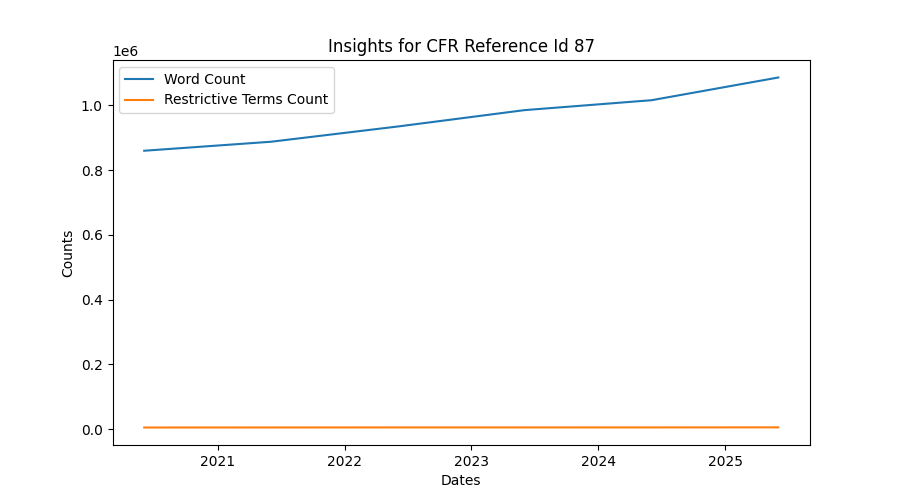

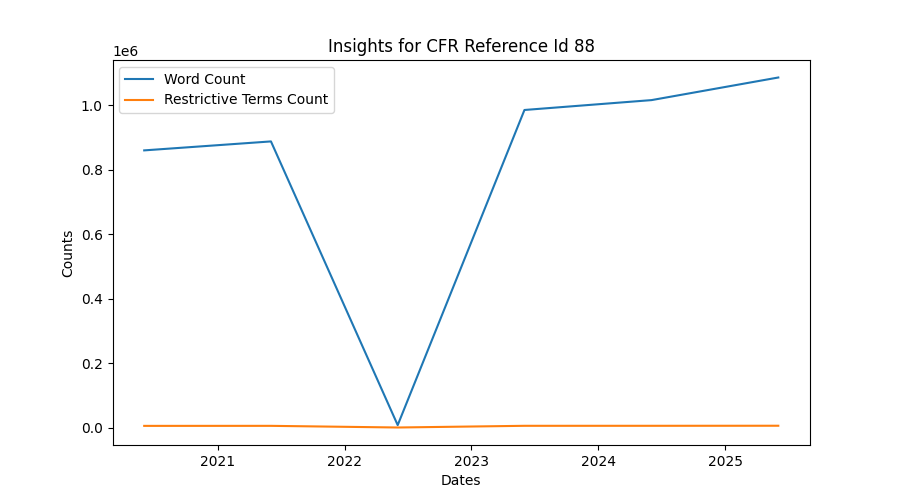

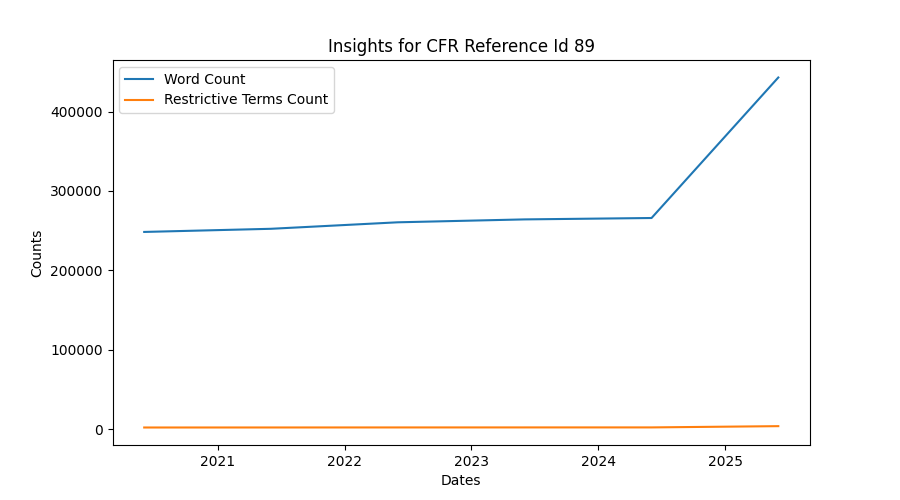

In [7]:
for key, value in insights_by_reference_id.items():
    value.sort(key=lambda d: d["date"])
    y_word_counts = [d.get("word_count") for d in value]
    y_restrictive_terms_counts = [d.get("restrictive_terms_count") for d in value]
    x_dates = pd.to_datetime([d.get("date") for d in value])
    plt.figure(figsize=(9, 5))
    plt.plot(x_dates, y_word_counts)
    plt.plot(x_dates, y_restrictive_terms_counts)
    plt.title("Insights for CFR Reference Id " + str(key))
    plt.xlabel("Dates")
    plt.ylabel("Counts")
    plt.legend(["Word Count", "Restrictive Terms Count"])
    plt.show()